In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## LOAD DATASET

In [5]:
df = pd.read_csv("C:/Users/Lenovo/Documents/Retail-Store-Sales-Data Science/Data/Raw/retail_store_sales.csv")

First 5 rows

In [18]:
# Display the first 5 rows

df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


Check Dataset Size

In [19]:
# Check the number of rows and columns

df.shape

(12575, 11)

Check Column Names

In [17]:
# Display all column names in the dataset

df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

Dataset Information

In [15]:
# Check column data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


Statistical Summary

In [14]:
# Generate statistical summary for numerical columns

df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


Check Missing Values

In [20]:
# Check the number of missing values in each column

df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

Check Duplicate Records

In [21]:
# Check how many duplicate rows exist

df.duplicated().sum()

np.int64(0)

Check Unique Values

In [22]:
# Display unique values for important categorical columns

print("Categories:")
print(df["Category"].unique())

print("\nPayment Methods:")
print(df["Payment Method"].unique())

print("\nLocations:")
print(df["Location"].unique())

Categories:
['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']

Payment Methods:
['Digital Wallet' 'Credit Card' 'Cash']

Locations:
['Online' 'In-store']


Convert Date Column

In [23]:
# Convert Transaction Date into datetime format

df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

# Check the updated data type
df["Transaction Date"].dtype

dtype('<M8[ns]')

Clean Missing Values

In [25]:
# Fill missing Item values with "Unknown"
df["Item"] = df["Item"].fillna("Unknown")

# Fill missing numerical values using the median
df["Price Per Unit"] = df["Price Per Unit"].fillna(
    df["Price Per Unit"].median()
)

df["Quantity"] = df["Quantity"].fillna(
    df["Quantity"].median()
)

# Fill missing Total Spent using Price Per Unit × Quantity
df["Total Spent"] = df["Total Spent"].fillna(
    df["Price Per Unit"] * df["Quantity"]
)

# Fill missing Discount Applied with False
df["Discount Applied"] = df["Discount Applied"].fillna(False)

Verify Cleaning

In [26]:
# Check whether any missing values remain

df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

Remove Duplicates

In [27]:
# Remove duplicate records from the dataset

df = df.drop_duplicates()

# Check duplicate count after cleaning
df.duplicated().sum()

np.int64(0)

Outlier Detection

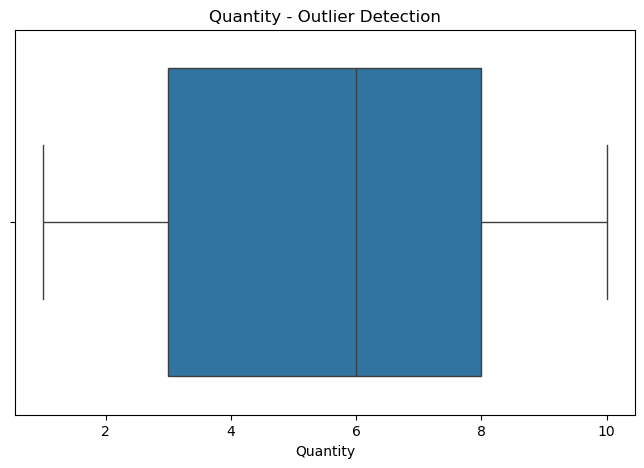

In [28]:
# Visualize outliers in Quantity using a boxplot

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Quantity"])

plt.title("Quantity - Outlier Detection")
plt.xlabel("Quantity")

plt.show()

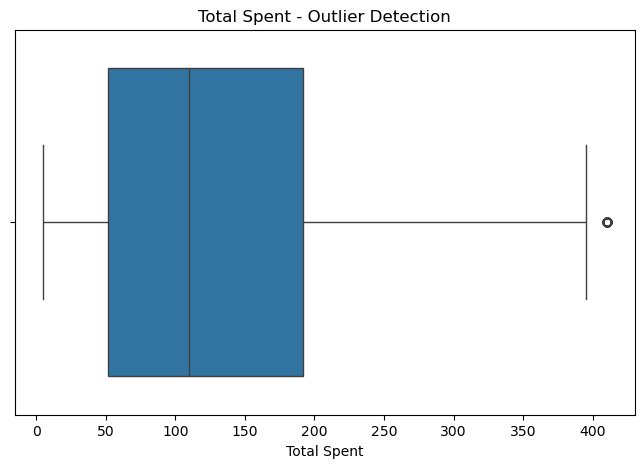

In [29]:
# Visualize outliers in Total Spent

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Total Spent"])

plt.title("Total Spent - Outlier Detection")
plt.xlabel("Total Spent")

plt.show()

Save Cleaned Dataset

In [31]:
# Check the current working directory
import os

print(os.getcwd())

c:\Users\Lenovo\Documents\Retail-Store-Sales-Data Science\Data cleaning and visualization


In [32]:
# Import os library
import os

# Create the cleaned folder if it does not already exist
os.makedirs("../data/cleaned", exist_ok=True)

# Save the cleaned dataset
df.to_csv(
    "../data/cleaned/retail_store_sales_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [33]:
# Check whether the cleaned CSV file exists

import os

file_path = "../data/cleaned/retail_store_sales_cleaned.csv"

if os.path.exists(file_path):
    print("File saved successfully!")
    print("Location:", os.path.abspath(file_path))
else:
    print("File was not saved.")

File saved successfully!
Location: c:\Users\Lenovo\Documents\Retail-Store-Sales-Data Science\data\cleaned\retail_store_sales_cleaned.csv


# Visualization 1

Sales by Category

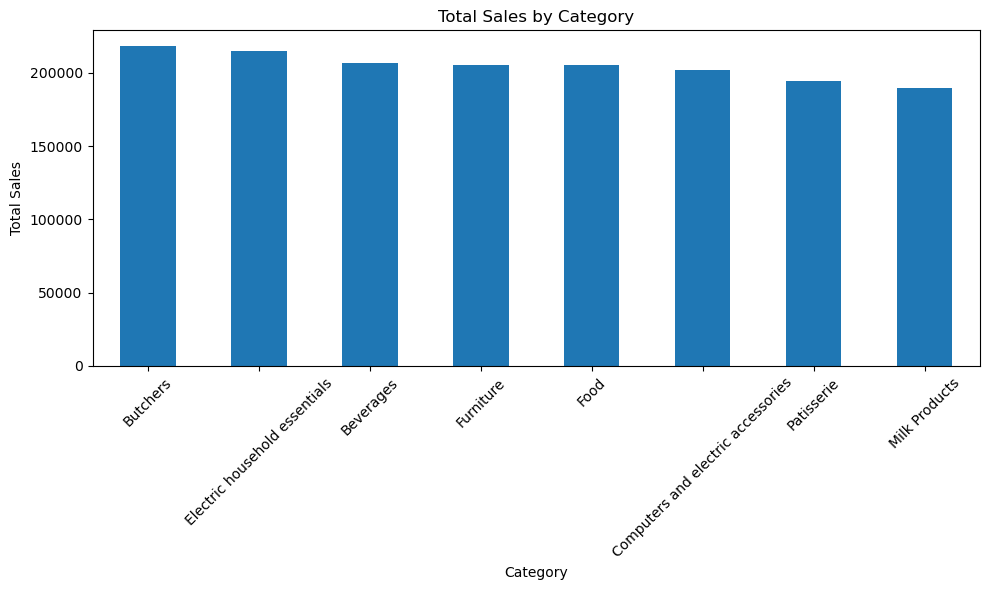

In [38]:
# Calculate total sales for each category

category_sales = df.groupby("Category")["Total Spent"].sum()

# Create a bar chart

plt.figure(figsize=(10, 6))

category_sales.sort_values(ascending=False).plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visualizations/sales_by_category.png")
plt.show()

# Visualization 2

Payment Method

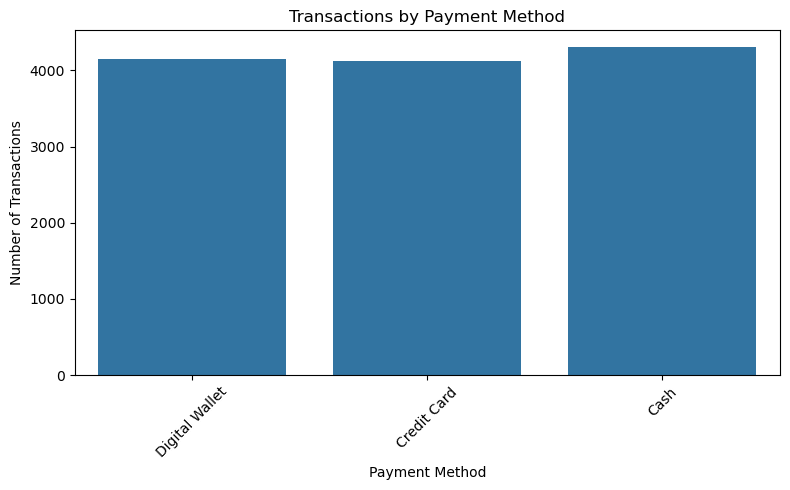

In [39]:
# Count transactions for each payment method

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Payment Method")

plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visualizations/payment_method.png")

plt.show()

# Visualization 3

Location

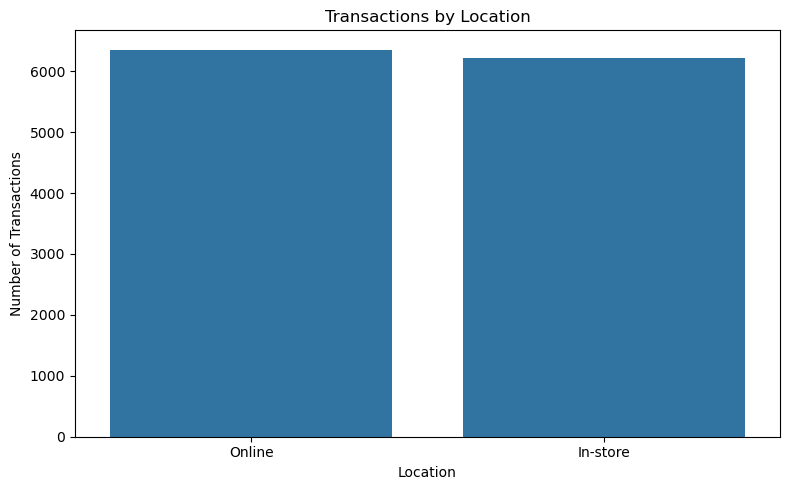

In [41]:
# Analyze the number of transactions by location

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Location")

plt.title("Transactions by Location")
plt.xlabel("Location")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../visualizations/location_analysis.png")

plt.show()

# Visualization 4

Quantity Distribution

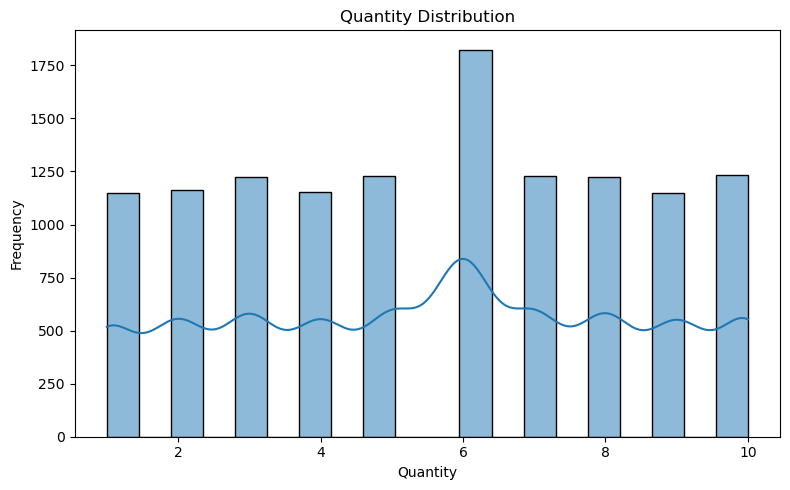

In [42]:
# Display the distribution of purchased quantities

plt.figure(figsize=(8, 5))

sns.histplot(df["Quantity"], bins=20, kde=True)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../visualizations/quantity_distribution.png")

plt.show()

# Visualization 5

Price vs Quantity

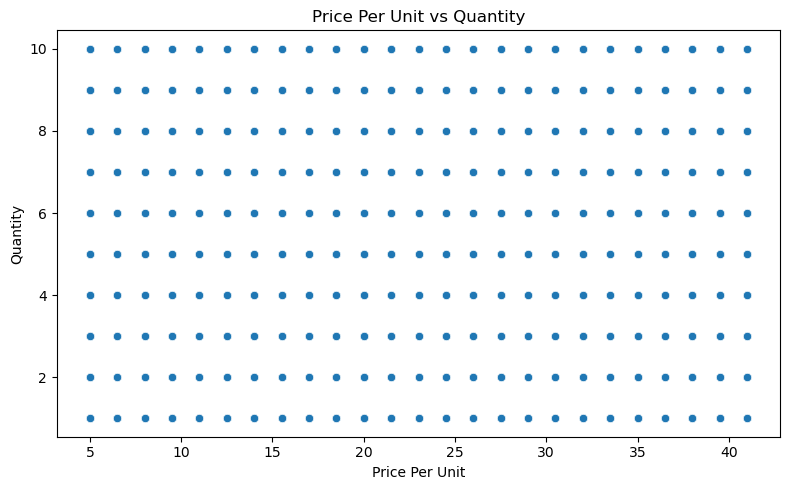

In [43]:
# Analyze the relationship between price and quantity

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Price Per Unit",
    y="Quantity"
)

plt.title("Price Per Unit vs Quantity")
plt.xlabel("Price Per Unit")
plt.ylabel("Quantity")

plt.tight_layout()

plt.savefig("../visualizations/price_vs_quantity.png")

plt.show()

Correlation Heatmap

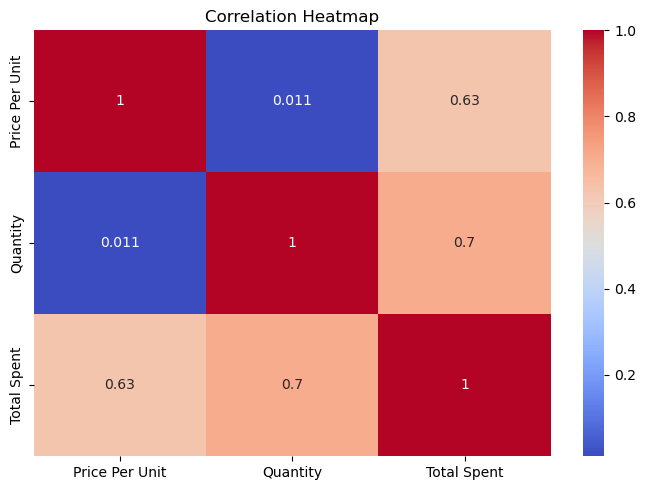

In [44]:
# Select numerical columns for correlation analysis

numeric_columns = [
    "Price Per Unit",
    "Quantity",
    "Total Spent"
]

# Create correlation matrix

correlation = df[numeric_columns].corr()

# Visualize the correlation matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("../visualizations/correlation_heatmap.png")

plt.show()

## Key Insights

1. The dataset contains retail transaction information including
   products, prices, quantities, payment methods and locations.

2. Missing values were identified and handled using suitable
   techniques.

3. Duplicate records were checked and removed.

4. Boxplots were used to identify potential outliers.

5. Different visualizations were created to understand sales,
   payment methods, locations and purchasing behavior.

6. Correlation analysis was performed to understand relationships
   between price, quantity and total spending.